# Part 1: CIFAR-10 Image Classification

ECS7026P Neural Networks and Deep Learning  
Architecture: intermediate blocks (L independent convs, gated by FC on channel means) + output block.

## 1. Setup

In [ ]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as T
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

# Optional: fix seeds for reproducibility
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

Device: cuda


## 2. Data

In [2]:
CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD  = (0.2470, 0.2435, 0.2616)

train_tf = T.Compose([
    T.RandomCrop(32, padding=4),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize(CIFAR_MEAN, CIFAR_STD),
])
test_tf  = T.Compose([
    T.ToTensor(),
    T.Normalize(CIFAR_MEAN, CIFAR_STD),
])

train_ds = torchvision.datasets.CIFAR10(root='./data', train=True,  download=True, transform=train_tf)
test_ds  = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=test_tf)

batch_size = 128
num_workers = 2
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=num_workers)

# Sanity check
X, y = next(iter(train_loader))
print(f'Train batch: X {X.shape}, y {y.shape}')

100%|██████████| 170M/170M [00:09<00:00, 17.6MB/s] 


Train batch: X torch.Size([128, 3, 32, 32]), y torch.Size([128])


## 3. Model: Intermediate block

In [3]:
class IntermediateBlock(nn.Module):
    """
    Input x [B, c_in, H, W]. L independent conv branches, all receive same x.
    Gate: channel-wise mean -> FC -> softmax -> a. Output x' = a1*C1(x) + ... + aL*CL(x).
    """
    def __init__(self, c_in, c_out, L=3, kernel_sizes=(3, 5, 3), paddings=(1, 2, 2), dilations=(1, 1, 2)):
        super().__init__()
        self.L = L
        self.convs = nn.ModuleList()
        for k, p, d in zip(kernel_sizes, paddings, dilations):
            self.convs.append(nn.Sequential(
                nn.Conv2d(c_in, c_out, kernel_size=k, padding=p, dilation=d),
                nn.BatchNorm2d(c_out),
                nn.ReLU(inplace=True),
            ))
        self.gate_fc = nn.Linear(c_in, L)

    def forward(self, x):
        # m: [B, c_in]
        m = x.mean(dim=(2, 3))
        a = self.gate_fc(m)  # [B, L]
        a = a.softmax(dim=1)
        outs = [conv(x) for conv in self.convs]  # each [B, c_out, H, W]
        # Stack [B, L, c_out, H, W], then weighted sum with a [B, L, 1, 1, 1]
        stacked = torch.stack(outs, dim=1)
        a = a.view(a.size(0), a.size(1), 1, 1, 1)
        out = (stacked * a).sum(dim=1)
        return out

## 4. Model: Output block

In [4]:
class OutputBlock(nn.Module):
    """
    Input x [B, c, H, W]. Global channel mean -> MLP -> logits [B, 10].
    """
    def __init__(self, c_in, num_classes=10, hidden=256, dropout=0.3):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(c_in, hidden),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(hidden, num_classes),
        )

    def forward(self, x):
        m = x.mean(dim=(2, 3))  # [B, c_in]
        return self.mlp(m)

## 5. Full network

In [5]:
class CIFARNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.b1 = IntermediateBlock(3,   64,  L=3)
        self.b2 = IntermediateBlock(64,  128, L=3)
        self.b3 = IntermediateBlock(128, 256, L=3)
        self.pool = nn.MaxPool2d(2)
        self.out = OutputBlock(256, num_classes=num_classes, hidden=256, dropout=0.3)

    def forward(self, x):
        x = self.b1(x)
        x = self.pool(x)
        x = self.b2(x)
        x = self.pool(x)
        x = self.b3(x)
        x = self.pool(x)
        return self.out(x)

model = CIFARNet().to(device)
print(model)
# Quick shape check
with torch.no_grad():
    out = model(X.to(device))
print(f'Output shape: {out.shape}')

CIFARNet(
  (b1): IntermediateBlock(
    (convs): ModuleList(
      (0): Sequential(
        (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
      )
      (1): Sequential(
        (0): Conv2d(3, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
      )
      (2): Sequential(
        (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(2, 2), dilation=(2, 2))
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
      )
    )
    (gate_fc): Linear(in_features=3, out_features=3, bias=True)
  )
  (b2): IntermediateBlock(
    (convs): ModuleList(
      (0): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), paddin

## 6. Training and evaluation helpers

In [ ]:
def accuracy(logits, y):
    pred = logits.argmax(dim=1)
    return (pred == y).float().sum().item()

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, total_correct, n = 0.0, 0, 0
    batch_losses = []
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(X)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * X.size(0)
        total_correct += accuracy(logits, y)
        n += X.size(0)
        batch_losses.append(loss.item())
    return total_loss / n, total_correct / n, batch_losses

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, total_correct, n = 0.0, 0, 0
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            logits = model(X)
            loss = criterion(logits, y)
            total_loss += loss.item() * X.size(0)
            total_correct += accuracy(logits, y)
            n += X.size(0)
    return total_loss / n, total_correct / n

## 7. Training loop (baseline)

In [ ]:
# num_epochs = 30
# criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
# optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=5e-4)
# scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

# batch_losses_all = []
# train_accs, test_accs = [], []
# best_test_acc = 0.0
# best_state = None

In [8]:
# for epoch in range(num_epochs):
#     train_loss, train_acc, batch_losses = train_one_epoch(model, train_loader, criterion, optimizer, device)
#     batch_losses_all.extend(batch_losses)
#     scheduler.step()
#     test_loss, test_acc = evaluate(model, test_loader, criterion, device)
#     train_accs.append(train_acc)
#     test_accs.append(test_acc)
#     if test_acc > best_test_acc:
#         best_test_acc = test_acc
#         best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
#     print(f'Epoch {epoch+1}/{num_epochs}  train_loss={train_loss:.4f}  train_acc={train_acc:.4f}  test_acc={test_acc:.4f}')

# print(f'\nBest test accuracy: {best_test_acc:.4f}')

## 8. Required plots

In [9]:
# fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# axes[0].plot(batch_losses_all, alpha=0.8)
# axes[0].set_xlabel('Training batch')
# axes[0].set_ylabel('Cross entropy loss')
# axes[0].set_title('Loss per training batch')
# axes[0].grid(True, alpha=0.3)

# axes[1].plot(train_accs, label='Training accuracy')
# axes[1].plot(test_accs, label='Testing accuracy')
# axes[1].set_xlabel('Epoch')
# axes[1].set_ylabel('Accuracy')
# axes[1].set_title('Accuracy per epoch')
# axes[1].legend(loc='best')
# axes[1].grid(True, alpha=0.3)

# plt.tight_layout()
# plt.show()

## 9. Restore best model and report

In [10]:
# if best_state is not None:
#     model.load_state_dict(best_state)
#     model = model.to(device)

# _, final_test_acc = evaluate(model, test_loader, criterion, device)
# print(f'Final test accuracy (best checkpoint): {final_test_acc:.4f}')

---
**Report checklist (Section 3.2)**  
- Architecture description and how it follows Section 1.2  
- Hyperparameters and techniques  
- Plot: loss per training batch  
- Plot: train and test accuracy per epoch  
- Highest test accuracy stated clearly  

**Optional:** More experiments (SGD, dropout, channels, etc.) in new cells; keep best run plots and state above.

## 10. Accuracy upgrade pack (SGD + stronger augmentation + experiment runner)

Run the following cells to train stronger variants while keeping the same assignment architecture.

In [11]:
# Stronger training transforms (adds RandomErasing)
train_tf_strong = T.Compose([
    T.RandomCrop(32, padding=4),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize(CIFAR_MEAN, CIFAR_STD),
    T.RandomErasing(p=0.25, scale=(0.02, 0.2), ratio=(0.3, 3.3), value='random'),
])

test_tf_strong = T.Compose([
    T.ToTensor(),
    T.Normalize(CIFAR_MEAN, CIFAR_STD),
])

train_ds_strong = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=train_tf_strong)
test_ds_strong  = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=test_tf_strong)

train_loader_strong = DataLoader(
    train_ds_strong,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=True,
)
test_loader_strong = DataLoader(
    test_ds_strong,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
)

print('Strong loaders ready:', len(train_loader_strong), len(test_loader_strong))

Strong loaders ready: 391 79


In [12]:
def run_experiment(
    exp_name,
    model_builder,
    train_loader,
    test_loader,
    num_epochs=120,
    lr=0.1,
    momentum=0.9,
    weight_decay=5e-4,
    label_smoothing=0.0,
):
    model = model_builder().to(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=lr,
        momentum=momentum,
        weight_decay=weight_decay,
        nesterov=True,
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

    batch_losses_all = []
    train_accs, test_accs = [], []
    best_test_acc = 0.0
    best_state = None

    for epoch in range(num_epochs):
        train_loss, train_acc, batch_losses = train_one_epoch(model, train_loader, criterion, optimizer, device)
        test_loss, test_acc = evaluate(model, test_loader, criterion, device)

        batch_losses_all.extend(batch_losses)
        train_accs.append(train_acc)
        test_accs.append(test_acc)

        if test_acc > best_test_acc:
            best_test_acc = test_acc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        scheduler.step()

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(
                f"[{exp_name}] Epoch {epoch + 1}/{num_epochs} "
                f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} test_loss={test_loss:.4f} test_acc={test_acc:.4f}"
            )

    # Restore best checkpoint
    if best_state is not None:
        model.load_state_dict(best_state)
        model = model.to(device)

    print(f"[{exp_name}] Best test accuracy: {best_test_acc:.4f}")

    return {
        'name': exp_name,
        'model': model,
        'best_test_acc': best_test_acc,
        'batch_losses': batch_losses_all,
        'train_accs': train_accs,
        'test_accs': test_accs,
        'num_epochs': num_epochs,
        'lr': lr,
        'momentum': momentum,
        'weight_decay': weight_decay,
        'label_smoothing': label_smoothing,
    }

In [13]:
# Optional wider variant (capacity boost)
class CIFARNetWide(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.b1 = IntermediateBlock(3,   96,  L=3)
        self.b2 = IntermediateBlock(96,  192, L=3)
        self.b3 = IntermediateBlock(192, 384, L=3)
        self.pool = nn.MaxPool2d(2)
        self.out = OutputBlock(384, num_classes=num_classes, hidden=384, dropout=0.3)

    def forward(self, x):
        x = self.b1(x)
        x = self.pool(x)
        x = self.b2(x)
        x = self.pool(x)
        x = self.b3(x)
        x = self.pool(x)
        return self.out(x)

In [14]:
# Run a compact experiment set
results = []

results.append(run_experiment(
    exp_name='sgd_baseline',
    model_builder=CIFARNet,
    train_loader=train_loader,
    test_loader=test_loader,
    num_epochs=120,
    lr=0.1,
    momentum=0.9,
    weight_decay=5e-4,
    label_smoothing=0.0,
))

results.append(run_experiment(
    exp_name='sgd_strong_aug_ls005',
    model_builder=CIFARNet,
    train_loader=train_loader_strong,
    test_loader=test_loader_strong,
    num_epochs=120,
    lr=0.1,
    momentum=0.9,
    weight_decay=5e-4,
    label_smoothing=0.05,
))

results.append(run_experiment(
    exp_name='sgd_wide_strong_aug_ls005',
    model_builder=CIFARNetWide,
    train_loader=train_loader_strong,
    test_loader=test_loader_strong,
    num_epochs=120,
    lr=0.1,
    momentum=0.9,
    weight_decay=5e-4,
    label_smoothing=0.05,
))

best_result = max(results, key=lambda r: r['best_test_acc'])
print('\nBest experiment:', best_result['name'])
print('Best test accuracy:', f"{best_result['best_test_acc']:.4f}")

[sgd_baseline] Epoch 1/120 train_loss=1.5572 train_acc=0.4176 test_loss=1.3267 test_acc=0.5007
[sgd_baseline] Epoch 10/120 train_loss=0.6604 train_acc=0.7739 test_loss=0.8071 test_acc=0.7245
[sgd_baseline] Epoch 20/120 train_loss=0.5582 train_acc=0.8089 test_loss=0.6050 test_acc=0.7845
[sgd_baseline] Epoch 30/120 train_loss=0.5141 train_acc=0.8248 test_loss=0.5940 test_acc=0.7941
[sgd_baseline] Epoch 40/120 train_loss=0.4771 train_acc=0.8377 test_loss=0.5082 test_acc=0.8240
[sgd_baseline] Epoch 50/120 train_loss=0.4392 train_acc=0.8509 test_loss=0.8385 test_acc=0.7240
[sgd_baseline] Epoch 60/120 train_loss=0.3963 train_acc=0.8650 test_loss=0.5858 test_acc=0.7986
[sgd_baseline] Epoch 70/120 train_loss=0.3464 train_acc=0.8835 test_loss=0.5729 test_acc=0.8110
[sgd_baseline] Epoch 80/120 train_loss=0.2862 train_acc=0.9030 test_loss=0.5137 test_acc=0.8331
[sgd_baseline] Epoch 90/120 train_loss=0.2173 train_acc=0.9285 test_loss=0.4514 test_acc=0.8557
[sgd_baseline] Epoch 100/120 train_loss=0

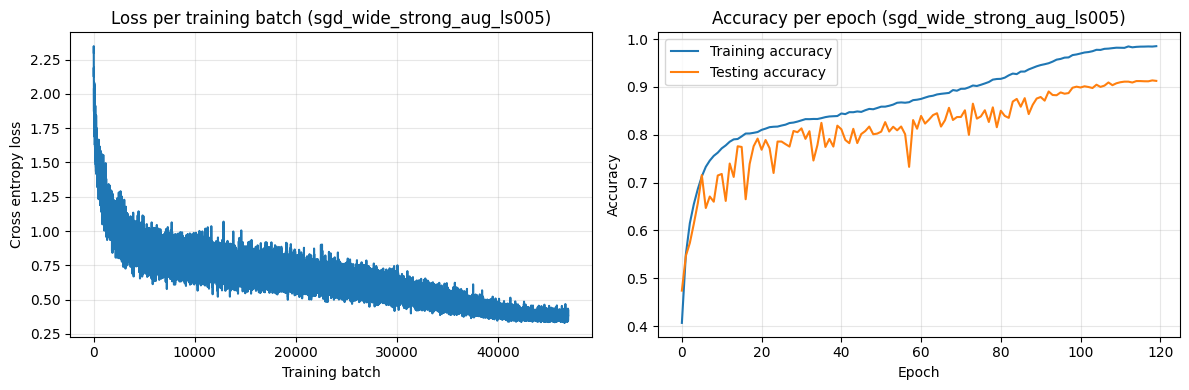

In [15]:
# Plot curves for the best experiment (use these for report if this beats the baseline)
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(best_result['batch_losses'])
plt.xlabel('Training batch')
plt.ylabel('Cross entropy loss')
plt.title(f"Loss per training batch ({best_result['name']})")
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(best_result['train_accs'], label='Training accuracy')
plt.plot(best_result['test_accs'], label='Testing accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title(f"Accuracy per epoch ({best_result['name']})")
plt.legend(loc='best')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Extra plots for the new experiment set (all runs)

# 1) Compare test-accuracy curves across all experiments
plt.figure(figsize=(12, 4))
for r in results:
    plt.plot(r['test_accs'], label=r['name'])
plt.xlabel('Epoch')
plt.ylabel('Test accuracy')
plt.title('Test accuracy comparison across experiments')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 2) Compare final train/test accuracy + generalization gap
names = [r['name'] for r in results]
final_train = [r['train_accs'][-1] for r in results]
final_test = [r['test_accs'][-1] for r in results]
gap = [tr - te for tr, te in zip(final_train, final_test)]

x = np.arange(len(names))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(x - width / 2, final_train, width, label='Final train acc')
axes[0].bar(x + width / 2, final_test, width, label='Final test acc')
axes[0].set_xticks(x)
axes[0].set_xticklabels(names, rotation=20, ha='right')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Final epoch accuracy by experiment')
axes[0].legend(loc='best')
axes[0].grid(True, axis='y', alpha=0.3)

axes[1].bar(names, gap)
axes[1].set_ylabel('Train acc - Test acc')
axes[1].set_title('Generalization gap (final epoch)')
axes[1].tick_params(axis='x', rotation=20)
axes[1].grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()
